In [1]:
import sys 
import os 

sys.path.append(os.path.join('..', '..'))

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import unicodedata
import geopandas as gpd

In [3]:
data_dir = Path("../../data/base_de_dados_final/")
arquivo = data_dir / "base_feature_engineering.csv"

In [4]:
df = pd.read_csv(arquivo, sep=";", encoding="latin1", dtype=str)

In [5]:
df.head(3)

,ATENDIMENTO_BAIRRO_NOME,FLAG_EQUIPAMENTO_URBANO,FLAG_FLAGRANTE,NATUREZA1_DEFESA_CIVIL,NATUREZA2_DEFESA_CIVIL,NATUREZA3_DEFESA_CIVIL,NATUREZA4_DEFESA_CIVIL,NATUREZA5_DEFESA_CIVIL,OCORRENCIA_DIA_SEMANA,OCORRENCIA_MES,...,OUTROS,log_rendimento,log_pop,rendimento_medio_responsavel_sm_estimado_norm,pct_alfabetizacao_15mais_estimado_norm,pct_sem_banheiro_sanitario_estimado_norm,pct_esgotamento_precario_estimado_norm,pct_sem_rede_geral_agua_estimado_norm,pct_lixo_destino_inadequado_estimado_norm,IQV_final
0,cidade industrial,0,0,0,0,0,0,0,5,1,...,0,1.2725655957915476,12.054569291774312,0.10430247718383312,0.5860284605433375,0.8524590163934427,0.9580992133568791,0.9939548202354438,0.9832635983263598,54.575836660173394
1,fazendinha,1,0,0,0,0,0,0,5,1,...,0,1.4445632692438664,10.249025712063943,0.1479791395045633,0.693402328589909,0.9344262295081966,0.981377428158613,0.9977728285077951,0.9916317991631799,60.589451314297285
2,uberaba,0,0,0,0,0,0,0,5,1,...,1,1.5933085305042167,11.181751169442313,0.19230769230769235,0.693402328589909,0.819672131147541,0.9049606678439557,0.960229080496341,0.9832635983263598,60.09137967837168


### Análise geoespacial dos bairros de Curitiba

Nesta seção, os indicadores socioeconômicos extraídos por bairro serão agrupados à base geográfica oficial do IPPUC, permitindo a geração de mapas de calor para a cidade de Curitiba. As variáveis representadas serão:

- `rendimento_medio_responsavel_sm_estimado_norm`;
- `pct_alfabetizacao_15mais_estimado_norm`;
- `pct_esgotamento_precario_estimado_norm`;
- `pct_sem_rede_geral_agua_estimado_norm`;
- `pct_lixo_destino_inadequado_estimado_norm`;
- `IQV_final`

In [6]:
features_geoespaciais = [
    "rendimento_medio_responsavel_sm_estimado_norm",
    "pct_alfabetizacao_15mais_estimado_norm",
    "pct_esgotamento_precario_estimado_norm",
    "pct_sem_rede_geral_agua_estimado_norm",
    "pct_lixo_destino_inadequado_estimado_norm",
    "IQV_final",
]

Os nomes das features serão trocados nos títulos para melhor entendimento e clareza:

In [7]:
titulo_features_geoespaciais = {
    "rendimento_medio_responsavel_sm_estimado_norm": "Rendimento médio do responsável (normalizado)",
    "pct_alfabetizacao_15mais_estimado_norm": "Alfabetização 15+ (normalizado)",
    "pct_esgotamento_precario_estimado_norm": "Esgotamento precário (normalizado)",
    "pct_sem_rede_geral_agua_estimado_norm": "Sem rede geral de água (normalizado)",
    "pct_lixo_destino_inadequado_estimado_norm": "Destino inadequado do lixo (normalizado)",
    "IQV_final": "Índice de Qualidade de Vida (IQV)",
}

Os bairros Alto da XV, Campo do Santana e Cidade Industrial possuem divergência entre o dataset e os nomes disponibilizados pelo IPUC, por isso, realizamos a alteração:

In [8]:
ajuste_bairros = {
    "alto da rua xv": "alto da xv",
    "campo de santana": "campo do santana",
    "cidade industrial de curitiba": "cidade industrial",
}

In [9]:
def normalizar_bairro(valor):
    if pd.isna(valor):
        return np.nan

    texto = str(valor).strip().lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = " ".join(texto.split())

    return ajuste_bairros.get(texto, texto)

Calcularemos também os indicadores médios ao longo dos anos agrupados por bairros:

In [10]:
dados_bairros = df[
    ["ATENDIMENTO_BAIRRO_NOME", "ano", *features_geoespaciais]
].copy()

In [11]:
dados_bairros["bairro_join"] = dados_bairros["ATENDIMENTO_BAIRRO_NOME"].apply(normalizar_bairro)

In [12]:
dados_bairros[features_geoespaciais] = dados_bairros[features_geoespaciais].apply(
    pd.to_numeric,
    errors="coerce"
)

In [13]:
medias_bairro = (
    dados_bairros
    .groupby(["bairro_join", "ano"], as_index=False)[features_geoespaciais]
    .mean()
    .groupby("bairro_join", as_index=False)[features_geoespaciais]
    .mean()
)

In [14]:
medias_bairro.head(3)

,bairro_join,rendimento_medio_responsavel_sm_estimado_norm,pct_alfabetizacao_15mais_estimado_norm,pct_esgotamento_precario_estimado_norm,pct_sem_rede_geral_agua_estimado_norm,pct_lixo_destino_inadequado_estimado_norm,IQV_final
0,abranches,0.207455,0.766152,0.826259,0.970279,0.936254,63.126199
1,agua verde,0.552880,0.977627,0.997365,0.993487,0.997293,84.251443
2,ahu,0.582138,0.986455,0.997516,0.973049,1.000000,85.374475


Agora, carregamos o mapa oficial de Curitiba:

In [15]:
url_bairros = (
    "https://geocuritiba.ippuc.org.br/server/rest/services/"
    "GeoCuritiba/Publico_Interno_GeoCuritiba_BaseCartografica_para_BC/"
    "MapServer/44/query?where=1%3D1&outFields=*&returnGeometry=true&outSR=4326&f=geojson"
)

In [16]:
mapa_bairros = gpd.read_file(url_bairros)

In [17]:
mapa_bairros.head(3)

,objectid,codigo,tipo,nome,fonte,cd_regional,nm_regional,geometriaaproximada,legislacao,coord_x,coord_y,st_area(shape),st_perimeter(shape),geometry
0,1,44,DIVISA DE BAIRROS,CAMPO COMPRIDO,Decreto Municipal 774 / 1975,5,REGIONAL SANTA FELICIDADE / REGIONAL PORTÃO,None,None,667792.182209,7.183620e+06,8.569837e+06,16637.629130,"POLYGON ((-49.34479 -25.43499, -49.34484 -25.4..."
1,2,68,DIVISA DE BAIRROS,AUGUSTA,Decreto Municipal 774 / 1975,11,REGIONAL CIC,None,None,663603.479659,7.181836e+06,9.172474e+06,22721.965804,"POLYGON ((-49.38607 -25.44354, -49.38617 -25.4..."
2,3,71,DIVISA DE BAIRROS,CAMPO DE SANTANA,Decreto Municipal 774 / 1975,12,REGIONAL TATUQUARA,None,None,668287.869936,7.167570e+06,2.157946e+07,26635.142087,"POLYGON ((-49.31135 -25.57071, -49.31149 -25.5..."


E então, mergeamos os indicadores ao mapa:

In [18]:
mapa_bairros["bairro_join"] = mapa_bairros["nome"].apply(normalizar_bairro)

In [19]:
gdf_bairros = mapa_bairros.merge(
    medias_bairro,
    on="bairro_join",
    how="left"
)

In [20]:
gdf_bairros[["bairro_join", "IQV_final"]].head()

,bairro_join,IQV_final
0,campo comprido,68.049001
1,augusta,53.058675
2,campo do santana,54.640960
3,cidade industrial,57.867875
4,butiatuvinha,60.769209


### Plotando o mapa de calor dos indicadores

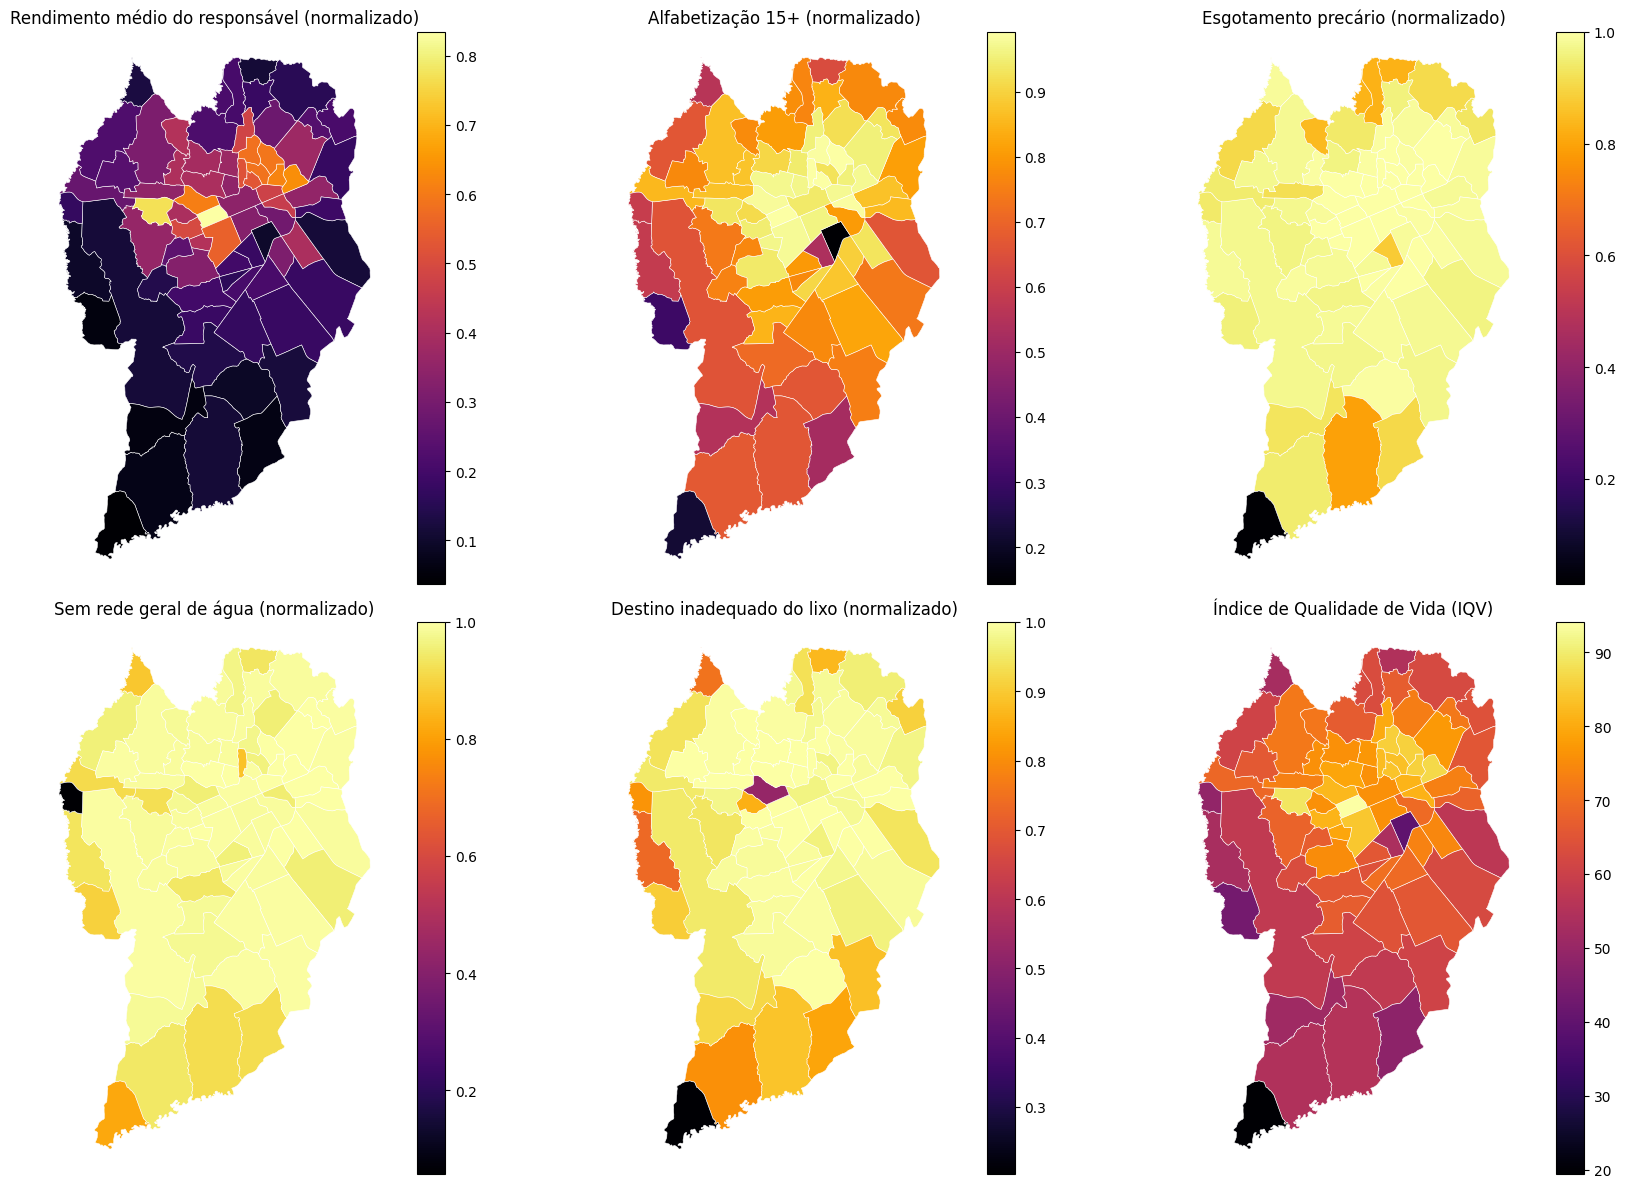

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, coluna in zip(axes.flat, features_geoespaciais):
    gdf_bairros.plot(
        column=coluna,
        ax=ax,
        cmap="inferno",
        legend=True,
        linewidth=0.4,
        edgecolor="white",
        missing_kwds={
            "color": "lightgrey",
            "label": "Sem dados"
        },
    )

    ax.set_title(titulo_features_geoespaciais[coluna], fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

Para a classificação do Índice de Qualidade de Vida por bairro, considera-se o IQV calculado pela seguinte expressão:

$$
\text{IQV}_{b} = \frac{100}{3}(x_{\text{renda, b}}^{\text{norm}} + x_{\text{alfabetização, b}}^{\text{norm}}) + \frac{100}{12}x_{\text{saneamento, b}}^{\text{norm}}
$$

em que o componente de saneamento é definido por:

$$
x_{\text{sanemanto, b}}^{\text{norm}} = x_{\text{banheiro, b}}^{\text{norm}} + x_{\text{esgotamento, b}}^{\text{norm}} + x_{\text{agua, b}}^{\text{norm}} + x_{\text{lixo, b}}^{\text{norm}}
$$

A partir dos valores obtidos para cada bairro, o IQV será classificado em três categorias, com base nos percentis 25 e 75 da distribuição:

- $\text{IQV}{low}$: bairros com $\text{IQV}{b} \leq p_{25}$;
- $\text{IQV}{medium}$: bairros com $p{25} < \text{IQV}{b} < p{75}$;
- $\text{IQV}{high}$: bairros com $\text{IQV}{b} \geq p_{75}$.

In [22]:
p25 = gdf_bairros["IQV_final"].quantile(0.25)
p75 = gdf_bairros["IQV_final"].quantile(0.75)

print(f"P25: {p25:.2f}")
print(f"P75: {p75:.2f}")

P25: 62.50
P75: 76.52


In [23]:
gdf_bairros["IQV_low"] = gdf_bairros["IQV_final"] <= p25

gdf_bairros["IQV_medium"] = (
    (gdf_bairros["IQV_final"] > p25) &
    (gdf_bairros["IQV_final"] < p75)
)

gdf_bairros["IQV_high"] = gdf_bairros["IQV_final"] >= p75

In [24]:
gdf_bairros["IQV_categoria"] = np.select(
    [
        gdf_bairros["IQV_low"],
        gdf_bairros["IQV_medium"],
        gdf_bairros["IQV_high"]
    ],
    [
        "IQV baixo",
        "IQV médio",
        "IQV alto"
    ],
    default="Sem dados"
)

gdf_bairros[["bairro_join", "IQV_final", "IQV_categoria"]].head()

,bairro_join,IQV_final,IQV_categoria
0,campo comprido,68.049001,IQV médio
1,augusta,53.058675,IQV baixo
2,campo do santana,54.640960,IQV baixo
3,cidade industrial,57.867875,IQV baixo
4,butiatuvinha,60.769209,IQV baixo


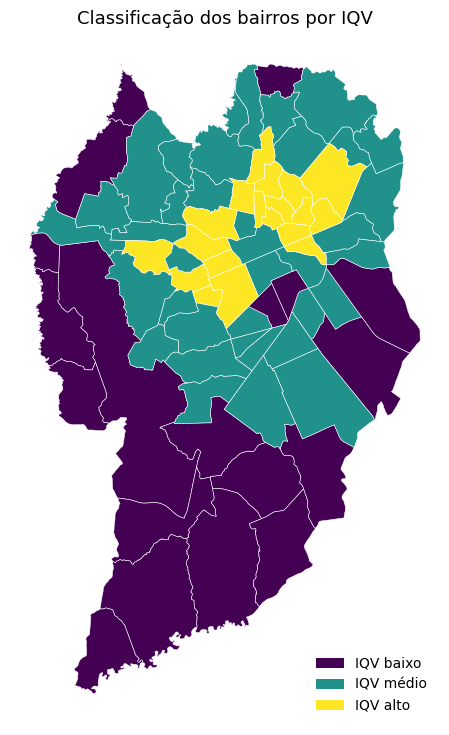

In [25]:
cores_iqv = {
    "IQV baixo": "#440154",
    "IQV médio": "#21918c",
    "IQV alto": "#fde725",
}

fig, ax = plt.subplots(figsize=(9, 9))

gdf_bairros.plot(
    color=gdf_bairros["IQV_categoria"].map(cores_iqv),
    linewidth=0.4,
    edgecolor="white",
    ax=ax
)

legenda = [
    Patch(facecolor=cor, label=categoria)
    for categoria, cor in cores_iqv.items()
]

ax.legend(handles=legenda, loc="lower right", frameon=False)
ax.set_title("Classificação dos bairros por IQV", fontsize=13)
ax.axis("off")

plt.show()